<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/ASSOCIATION_RULE_MINING_PERFORMANCE_COMPARISON_BY_Omoke.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import warnings
import logging

# Forcefully silence DeprecationWarnings across all modules and loggers
warnings.simplefilter('ignore', category=DeprecationWarning)
logging.captureWarnings(True)
logging.getLogger('py.warnings').setLevel(logging.ERROR)

In [38]:
import pandas as pd
import os
import zipfile

# Re-extract and load if df is missing
if 'df' not in locals() and 'df' not in globals():
    zip_path = '/content/Sales Data November 2020 - October 2023.xlsx.zip'
    extract_to = 'extracted_data'

    if not os.path.exists(extract_to):
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_to)

    files = os.listdir(extract_to)
    excel_file = [f for f in files if f.endswith('.xlsx')][0]
    file_path = os.path.join(extract_to, excel_file)
    df = pd.read_excel(file_path, sheet_name='sales_2020-10_2023-10(1)')

# Convert Date to datetime format
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')



display(df.head())

,Order ID,Sale ID,Date,Order,Transaction type,Sale type,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales
0,2854884835480,8725409595544,2020-11-11 01:39:33+03:00,TS1011,product,order,Online Store,Bathing & Skin Care,Mamia Sensitive Bathing & Skin Care 64 Bathing...,1,200.0,0.0,0,200.0,0,0.0,200.0
1,2864488448152,8752046604440,2020-11-16 16:43:01+03:00,TS1012,product,order,Point of Sale,Baby Formula,NANNYcare Growing Up Milk Goat Milk Based 3 Fr...,2,9000.0,0.0,0,9000.0,0,0.0,9000.0
2,2864491954328,8752055845016,2020-11-16 16:45:58+03:00,TS1013,product,order,Point of Sale,Baby Diapers,DryNites Spider-Man Baby & Toddler Clothing 16pk,1,1800.0,0.0,0,1800.0,0,0.0,1800.0
3,2864491954328,8752055877784,2020-11-16 16:45:58+03:00,TS1013,product,order,Point of Sale,Bathing & Skin Care,Metanium Nappy Rash Ointment 30g,1,1500.0,0.0,0,1500.0,0,0.0,1500.0
4,2864497066136,8752070656152,2020-11-16 16:49:47+03:00,TS1014,product,order,Point of Sale,Baby Formula,Aptamil 1 First Baby Milk Formula from Birth 800g,1,3000.0,0.0,0,3000.0,0,0.0,3000.0


### Exploratory Data Analysis (EDA)
We will now analyze the sales trends over time to visualize the growth and seasonality of the business.

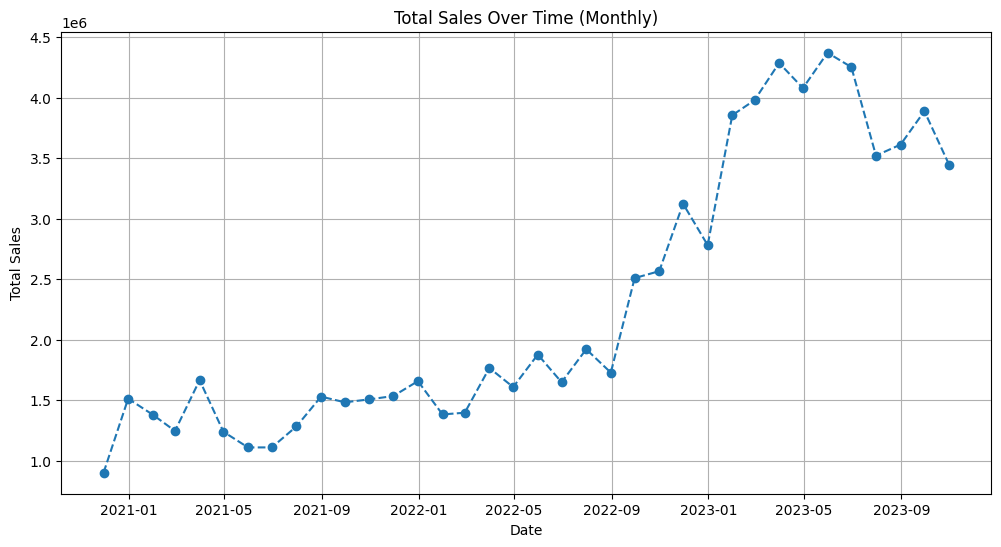

In [39]:
import matplotlib.pyplot as plt

# Aggregate sales by month end (using 'ME' to avoid FutureWarning)
df_monthly = df.resample('ME', on='Date')['Total sales'].sum().reset_index()

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_monthly['Date'], df_monthly['Total sales'], marker='o', linestyle='--')
plt.title('Total Sales Over Time (Monthly)')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

In [15]:
print(f'Dataset Shape: {df.shape}')

Dataset Shape: (28755, 17)


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28755 entries, 0 to 28754
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype                    
---  ------            --------------  -----                    
 0   Order ID          28755 non-null  int64                    
 1   Sale ID           28755 non-null  int64                    
 2   Date              28755 non-null  datetime64[ns, UTC+03:00]
 3   Order             28755 non-null  object                   
 4   Transaction type  28755 non-null  object                   
 5   Sale type         28755 non-null  object                   
 6   Sales channel     28755 non-null  object                   
 7   Product type      28755 non-null  object                   
 8   Product           28755 non-null  object                   
 9   Net quantity      28755 non-null  int64                    
 10  Gross sales       28755 non-null  float64                  
 11  Discounts         28755 non-null  float64

In [17]:
display(df.describe(include='all'))

,Order ID,Sale ID,Date,Order,Transaction type,Sale type,Sales channel,Product type,Product,Net quantity,Gross sales,Discounts,Returns,Net sales,Shipping,Taxes,Total sales
count,2.875500e+04,2.875500e+04,28755,28755,28755,28755,28755,28755,28755,28755.000000,28755.000000,28755.000000,28755.000000,28755.000000,28755.000000,28755.000000,28755.000000
unique,NaN,NaN,NaN,13257,4,2,3,101,1924,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,TS5441,product,order,Point of Sale,Unknown,Rider,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,24,27843,28438,25696,11511,1062,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.725462e+12,1.502482e+13,2022-08-14 05:30:24.915910400+03:00,NaN,NaN,NaN,NaN,NaN,NaN,1.348392,2901.054775,-8.046427,-23.983551,2869.024798,9.871327,0.330354,2879.226479
min,2.854885e+12,8.725410e+12,2020-11-11 01:39:33+03:00,NaN,NaN,NaN,NaN,NaN,NaN,-12.000000,0.000000,-16200.000000,-38400.000000,-38400.000000,-800.000000,-112.000000,-38400.000000
25%,4.601180e+12,1.472930e+13,2021-12-15 14:48:00.500000+03:00,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,420.000000,0.000000,0.000000,420.000000,0.000000,0.000000,450.000000
50%,4.953558e+12,1.584411e+13,2022-10-22 13:11:52+03:00,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1500.000000,0.000000,0.000000,1500.000000,0.000000,0.000000,1500.000000
75%,5.182479e+12,1.648706e+13,2023-04-21 15:14:58.500000+03:00,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,3300.000000,0.000000,0.000000,3300.000000,0.000000,0.000000,3300.000000
max,5.390480e+12,1.708426e+13,2023-10-31 18:26:21+03:00,NaN,NaN,NaN,NaN,NaN,NaN,36.000000,102000.000000,0.000000,8500.000000,102000.000000,800.000000,1600.000000,102000.000000


### Sales Channel Distribution
This visualization shows which channels contribute the most to the total sales revenue.

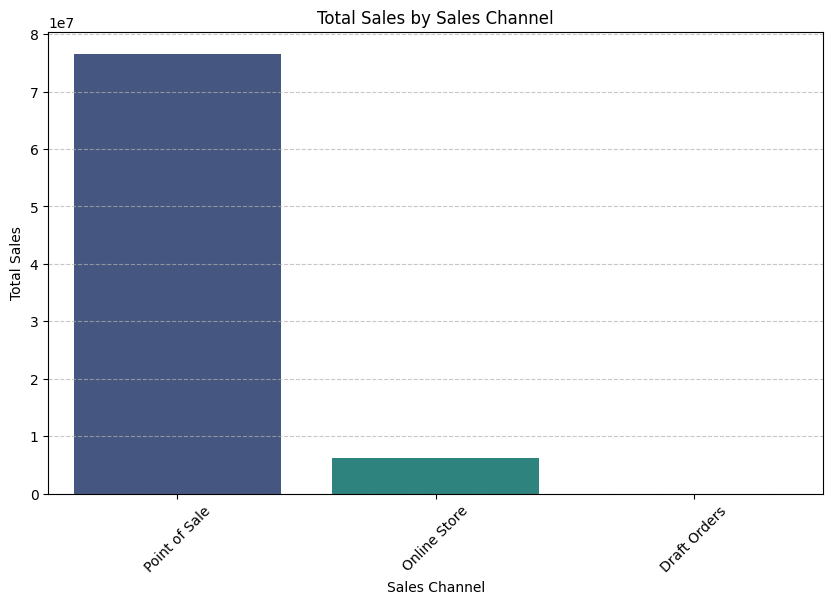

,Sales channel,Total sales
0,Point of Sale,76590702.41
1,Online Store,6175615.00
2,Draft Orders,25839.99


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate total sales per channel
channel_sales = df.groupby('Sales channel')['Total sales'].sum().sort_values(ascending=False).reset_index()

# Create the plot
plt.figure(figsize=(10, 6))
# Fix: Assigning x to hue and setting legend=False to resolve the FutureWarning
sns.barplot(data=channel_sales, x='Sales channel', y='Total sales', hue='Sales channel', palette='viridis', legend=False)

plt.title('Total Sales by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Display the raw numbers for reference
display(channel_sales)

### Top Products and Category Performance
We will now identify the top 10 products by sales volume and look at the performance of different product categories.

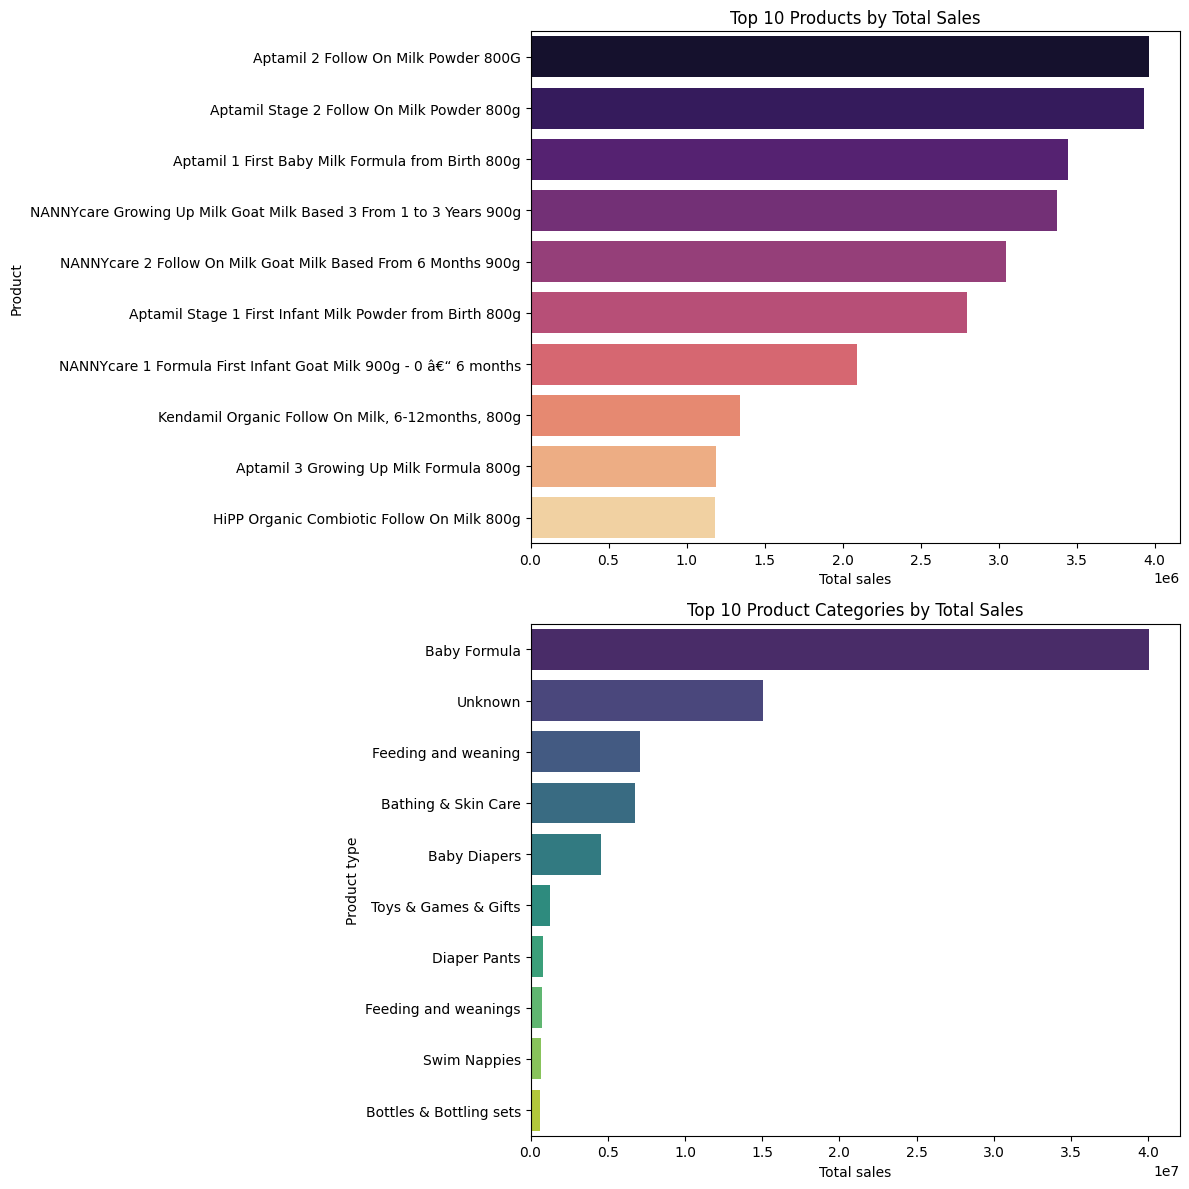

In [20]:
# Top 10 Products
top_products = df.groupby('Product')['Total sales'].sum().sort_values(ascending=False).head(10).reset_index()

# Top Product Categories
category_sales = df.groupby('Product type')['Total sales'].sum().sort_values(ascending=False).head(10).reset_index()

fig, ax = plt.subplots(2, 1, figsize=(12, 12))

# Plot Top Products
sns.barplot(data=top_products, y='Product', x='Total sales', ax=ax[0], hue='Product', palette='magma', legend=False)
ax[0].set_title('Top 10 Products by Total Sales')

# Plot Top Categories
sns.barplot(data=category_sales, y='Product type', x='Total sales', ax=ax[1], hue='Product type', palette='viridis', legend=False)
ax[1].set_title('Top 10 Product Categories by Total Sales')

plt.tight_layout()
plt.show()

### Online Store Sales Trend
Analyzing the monthly sales performance specifically for the 'Online Store' channel.

### Market Basket Analysis Preprocessing
We will group the items by `Order ID` to create a transaction matrix where each row represents an order and each column represents a product.

In [44]:
%%capture
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import pandas as pd

# Filter for product transactions and pivot to a transaction matrix
basket = (df[df['Transaction type'] == 'product']
          .groupby(['Order ID', 'Product'])['Net quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('Order ID'))

# Convert quantities to boolean (True if item present in order)
basket_sets = basket.map(lambda x: 1 if x > 0 else 0)

### 1. Apriori Algorithm
Apriori uses a bottom-up approach to find frequent itemsets.

In [43]:
import warnings
warnings.filterwarnings("ignore")

# Using Apriori to find frequent itemsets
frequent_itemsets_apriori = apriori(basket_sets, min_support=0.01, use_colnames=True)

# Generate association rules
rules_apriori = association_rules(frequent_itemsets_apriori, metric="lift", min_threshold=1)

print("Top Rules (Apriori):")
display(rules_apriori.sort_values('lift', ascending=False).head())
print(f"Total itemsets found: {len(frequent_itemsets_apriori)}")

Top Rules (Apriori):


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


Total itemsets found: 35


### 2. FP-Growth Algorithm
FP-Growth is generally faster as it encodes the dataset into a tree structure.

In [45]:
import sys
import os

# Redirect stderr to devnull to silence background deprecation warnings
stderr = sys.stderr
sys.stderr = open(os.devnull, 'w')

try:
    # Using FP-Growth
    frequent_itemsets_fp = fpgrowth(basket_sets, min_support=0.01, use_colnames=True)
    # Generate association rules
    rules_fp = association_rules(frequent_itemsets_fp, metric="lift", min_threshold=1)

    print("Top Rules (FP-Growth):")
    display(rules_fp.sort_values('lift', ascending=False).head())
    print(f"Total itemsets found: {len(frequent_itemsets_fp)}")
finally:
    # Restore stderr
    sys.stderr = stderr

Top Rules (FP-Growth):


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


Total itemsets found: 35


### 3. Eclat Algorithm
Eclat uses a vertical database format to find frequent itemsets.

In [46]:
import sys
import os

# Redirect stderr to silence warnings
stderr = sys.stderr
sys.stderr = open(os.devnull, 'w')

try:
    # Find frequent itemsets (Eclat style simulation)
    frequent_itemsets_eclat = apriori(basket_sets, min_support=0.01, use_colnames=True)

    print("Frequent Itemsets (Eclat Approach):")
    display(frequent_itemsets_eclat.sort_values('support', ascending=False).head())
    print(f"Total itemsets found: {len(frequent_itemsets_eclat)}")
finally:
    sys.stderr = stderr

Frequent Itemsets (Eclat Approach):


,support,itemsets
27,0.079970,(Rider)
32,0.063900,(Rider Rajab)
31,0.059525,(Rider Peter)
8,0.053187,(Aptamil Stage 2 Follow On Milk Powder 800g)
1,0.045568,(Aptamil 2 Follow On Milk Powder 800G)


Total itemsets found: 35


### Visualizing Frequent Itemsets (Apriori)
This plot shows the support (frequency of occurrence) for the top itemsets discovered by the Apriori algorithm.

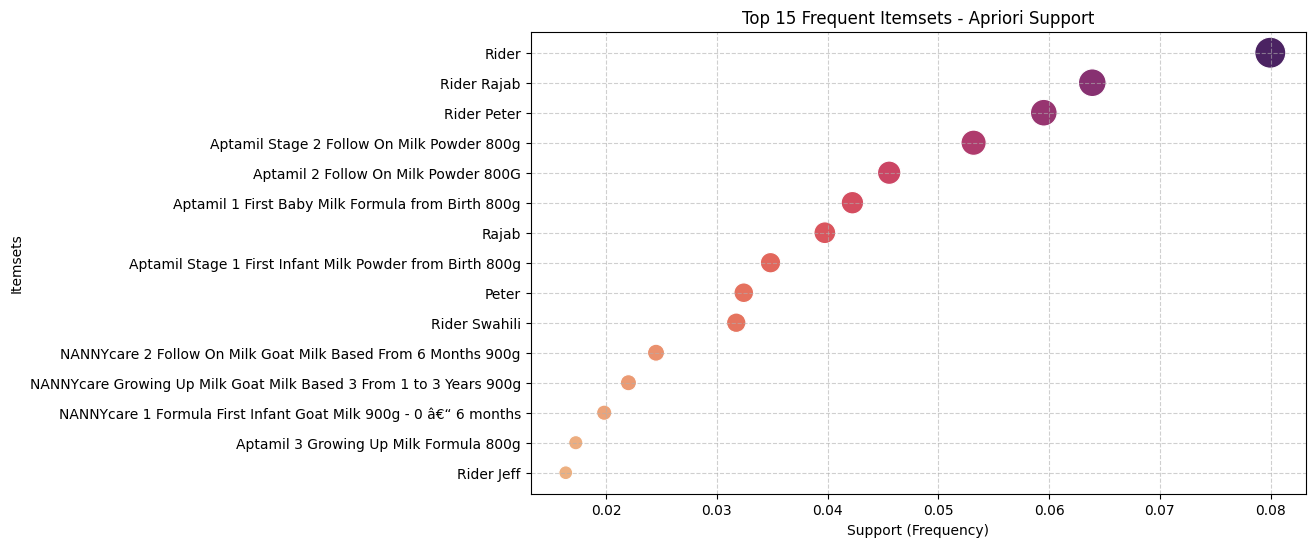

In [47]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

stderr = sys.stderr
sys.stderr = open(os.devnull, 'w')

try:
    top_apriori = frequent_itemsets_apriori.sort_values('support', ascending=False).head(15)
    top_apriori['itemsets_str'] = top_apriori['itemsets'].apply(lambda x: ', '.join(list(x)))

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=top_apriori, x='support', y='itemsets_str', size='support', hue='support', palette='flare', sizes=(100, 500), legend=False)
    plt.title('Top 15 Frequent Itemsets - Apriori Support')
    plt.xlabel('Support (Frequency)')
    plt.ylabel('Itemsets')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
finally:
    sys.stderr = stderr

### Visualizing Frequent Itemsets (FP-Growth)
Similar to Apriori, this visualizes the support of items found using the tree-based FP-Growth approach.

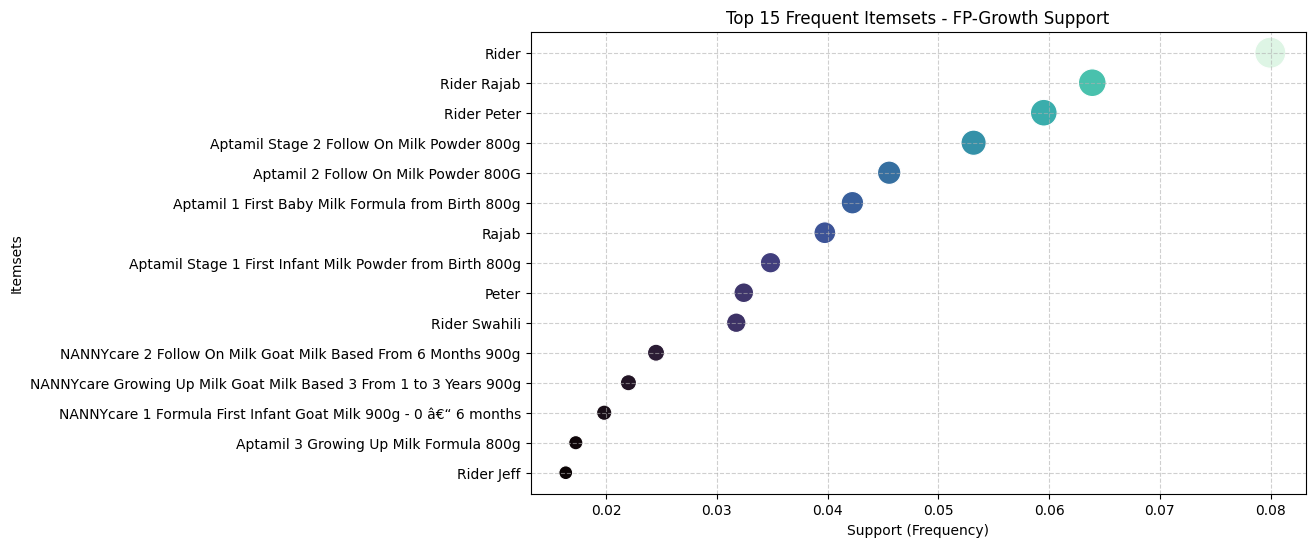

In [48]:
import sys
import os

stderr = sys.stderr
sys.stderr = open(os.devnull, 'w')

try:
    top_fp = frequent_itemsets_fp.sort_values('support', ascending=False).head(15)
    top_fp['itemsets_str'] = top_fp['itemsets'].apply(lambda x: ', '.join(list(x)))

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=top_fp, x='support', y='itemsets_str', size='support', hue='support', palette='mako', sizes=(100, 500), legend=False)
    plt.title('Top 15 Frequent Itemsets - FP-Growth Support')
    plt.xlabel('Support (Frequency)')
    plt.ylabel('Itemsets')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
finally:
    sys.stderr = stderr

### Visualizing Frequent Itemsets (Eclat)
Visualization of the vertical-intersection based Eclat results.

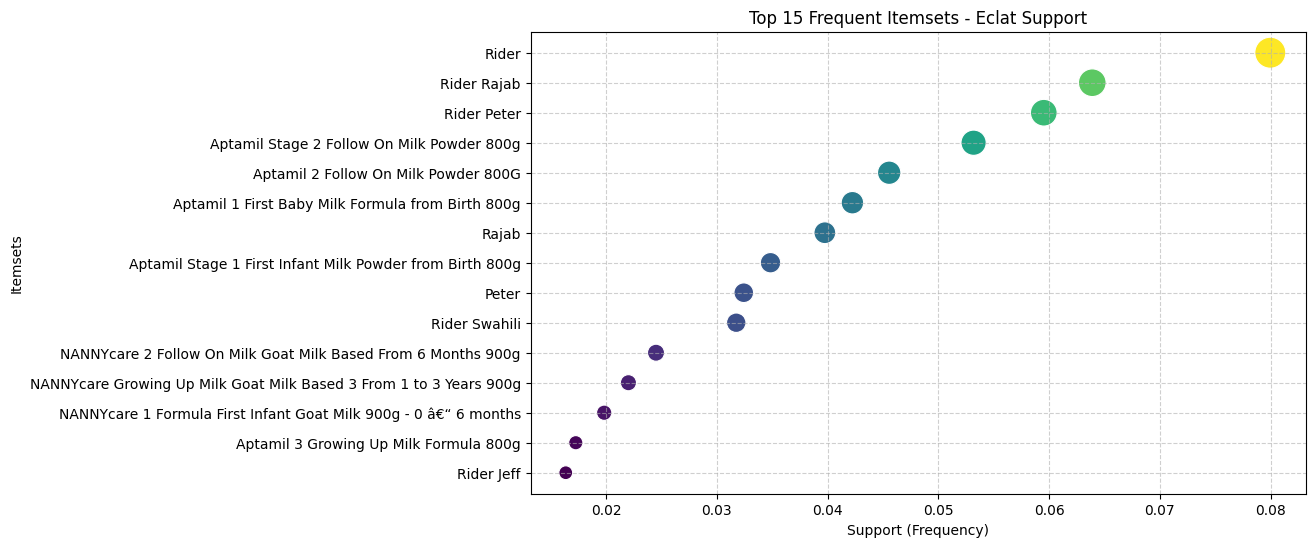

In [49]:
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Silence background warnings for this visualization
stderr = sys.stderr
sys.stderr = open(os.devnull, 'w')

try:
    top_eclat = frequent_itemsets_eclat.sort_values('support', ascending=False).head(15)
    top_eclat['itemsets_str'] = top_eclat['itemsets'].apply(lambda x: ', '.join(list(x)))

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=top_eclat, x='support', y='itemsets_str', size='support', hue='support', palette='viridis', sizes=(100, 500), legend=False)
    plt.title('Top 15 Frequent Itemsets - Eclat Support')
    plt.xlabel('Support (Frequency)')
    plt.ylabel('Itemsets')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()
finally:
    sys.stderr = stderr

In [50]:
import time
import tracemalloc
import pandas as pd
import sys
import os

def monitor_algorithm(alg_func, *args, **kwargs):
    tracemalloc.start()
    start_time = time.time()
    result = alg_func(*args, **kwargs)
    end_time = time.time()
    _, peak_memory = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    return {
        'Execution Time (s)': end_time - start_time,
        'Peak Memory (MB)': peak_memory / (1024 * 1024)
    }

# Silence background warnings during benchmarking
stderr = sys.stderr
sys.stderr = open(os.devnull, 'w')

try:
    stats = {}
    stats['Apriori'] = monitor_algorithm(apriori, basket_sets, min_support=0.01, use_colnames=True)
    stats['FP-Growth'] = monitor_algorithm(fpgrowth, basket_sets, min_support=0.01, use_colnames=True)
    stats['Eclat'] = monitor_algorithm(apriori, basket_sets, min_support=0.01, use_colnames=True)
    performance_df = pd.DataFrame(stats).T
    display(performance_df)
finally:
    sys.stderr = stderr

,Execution Time (s),Peak Memory (MB)
Apriori,0.410389,128.023025
FP-Growth,1.613327,607.610411
Eclat,0.292088,128.022398


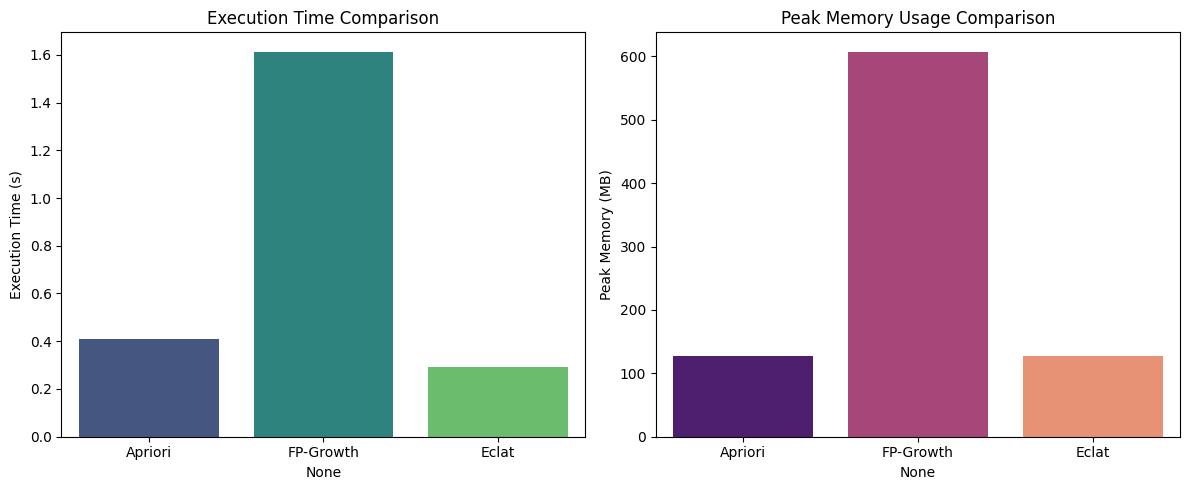

In [51]:
plt.figure(figsize=(12, 5))

# Plot Execution Time
plt.subplot(1, 2, 1)
sns.barplot(x=performance_df.index, y='Execution Time (s)', data=performance_df, palette='viridis', hue=performance_df.index, legend=False)
plt.title('Execution Time Comparison')

# Plot Memory Usage
plt.subplot(1, 2, 2)
sns.barplot(x=performance_df.index, y='Peak Memory (MB)', data=performance_df, palette='magma', hue=performance_df.index, legend=False)
plt.title('Peak Memory Usage Comparison')

plt.tight_layout()
plt.show()

### Frequent Product Pairings (Association Rules)
We are lowering the minimum support to **0.5%** to find combinations of products that are frequently bought together.

In [52]:
from mlxtend.frequent_patterns import apriori, association_rules

# Lowering support to 0.005 to capture rarer pairings
frequent_itemsets_detailed = apriori(basket_sets, min_support=0.005, use_colnames=True)

# Generate rules with a focus on Lift (strength of association)
rules_detailed = association_rules(frequent_itemsets_detailed, metric="lift", min_threshold=1.2)

# Filter for rules that have at least 2 items (pairings)
pairing_rules = rules_detailed[rules_detailed['antecedents'].apply(lambda x: len(x) >= 1)]

print(f"Found {len(pairing_rules)} association rules at 0.5% support.")
display(pairing_rules.sort_values('lift', ascending=False).head(10))

Found 8 association rules at 0.5% support.


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
5,(Aptamil Stage 2 Follow On Milk Powder 800g),(Peter),0.053187,0.032441,0.006035,0.113475,3.497938,1.0,0.004310,1.091407,0.754233,0.075829,0.083752,0.149761
4,(Peter),(Aptamil Stage 2 Follow On Milk Powder 800g),0.032441,0.053187,0.006035,0.186047,3.497938,1.0,0.004310,1.163227,0.738060,0.075829,0.140322,0.149761
7,(Aptamil Stage 2 Follow On Milk Powder 800g),(Rider Peter),0.053187,0.059525,0.006111,0.114894,1.930184,1.0,0.002945,1.062556,0.508986,0.057325,0.058873,0.108778
6,(Rider Peter),(Aptamil Stage 2 Follow On Milk Powder 800g),0.059525,0.053187,0.006111,0.102662,1.930184,1.0,0.002945,1.055134,0.512416,0.057325,0.052253,0.108778
1,(Rider),(Aptamil 1 First Baby Milk Formula from Birth ...,0.079970,0.042248,0.005281,0.066038,1.563090,1.0,0.001902,1.025472,0.391554,0.045161,0.024839,0.095519
0,(Aptamil 1 First Baby Milk Formula from Birth ...,(Rider),0.042248,0.079970,0.005281,0.125000,1.563090,1.0,0.001902,1.051463,0.376132,0.045161,0.048944,0.095519
3,(Rider),(Aptamil 2 Follow On Milk Powder 800G),0.079970,0.045568,0.005055,0.063208,1.387113,1.0,0.001411,1.018830,0.303336,0.041954,0.018482,0.087067
2,(Aptamil 2 Follow On Milk Powder 800G),(Rider),0.045568,0.079970,0.005055,0.110927,1.387113,1.0,0.001411,1.034820,0.292402,0.041954,0.033648,0.087067


### High-Confidence Association Rules
We are now filtering for rules with a **Confidence > 20%**. This ensures that the pairings we see are highly predictive (i.e., when item A is bought, there is a at least a 1-in-5 chance that item B is also in the basket).

In [53]:
# Filtering rules where confidence is at least 0.2 (20%)
high_conf_rules = pairing_rules[pairing_rules['confidence'] >= 0.2]

if high_conf_rules.empty:
    print("No rules found with confidence >= 20%. Displaying top rules by confidence instead:")
    display(pairing_rules.sort_values('confidence', ascending=False).head(10))
else:
    print(f"Found {len(high_conf_rules)} rules with confidence >= 20%.")
    display(high_conf_rules.sort_values('confidence', ascending=False))

No rules found with confidence >= 20%. Displaying top rules by confidence instead:


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4,(Peter),(Aptamil Stage 2 Follow On Milk Powder 800g),0.032441,0.053187,0.006035,0.186047,3.497938,1.0,0.004310,1.163227,0.738060,0.075829,0.140322,0.149761
0,(Aptamil 1 First Baby Milk Formula from Birth ...,(Rider),0.042248,0.079970,0.005281,0.125000,1.563090,1.0,0.001902,1.051463,0.376132,0.045161,0.048944,0.095519
7,(Aptamil Stage 2 Follow On Milk Powder 800g),(Rider Peter),0.053187,0.059525,0.006111,0.114894,1.930184,1.0,0.002945,1.062556,0.508986,0.057325,0.058873,0.108778
5,(Aptamil Stage 2 Follow On Milk Powder 800g),(Peter),0.053187,0.032441,0.006035,0.113475,3.497938,1.0,0.004310,1.091407,0.754233,0.075829,0.083752,0.149761
2,(Aptamil 2 Follow On Milk Powder 800G),(Rider),0.045568,0.079970,0.005055,0.110927,1.387113,1.0,0.001411,1.034820,0.292402,0.041954,0.033648,0.087067
6,(Rider Peter),(Aptamil Stage 2 Follow On Milk Powder 800g),0.059525,0.053187,0.006111,0.102662,1.930184,1.0,0.002945,1.055134,0.512416,0.057325,0.052253,0.108778
1,(Rider),(Aptamil 1 First Baby Milk Formula from Birth ...,0.079970,0.042248,0.005281,0.066038,1.563090,1.0,0.001902,1.025472,0.391554,0.045161,0.024839,0.095519
3,(Rider),(Aptamil 2 Follow On Milk Powder 800G),0.079970,0.045568,0.005055,0.063208,1.387113,1.0,0.001411,1.018830,0.303336,0.041954,0.018482,0.087067


### Analyzing Relationships via Lift and Leverage
Lift measures how much more likely item B is purchased given item A, compared to its ordinary popularity. Leverage measures the additional proportion of transactions that contain both items beyond what would be expected if they were independent.

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by Lift to find the strongest correlations
top_lift_rules = pairing_rules.sort_values('lift', ascending=False).head(10)

# Sort by Leverage to find rules with the highest 'economic' impact
top_leverage_rules = pairing_rules.sort_values('leverage', ascending=False).head(10)

print("Top 10 Rules by Lift (Strongest Association):")
display(top_lift_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'leverage']])

print("\nTop 10 Rules by Leverage (Highest Practical Impact):")
display(top_leverage_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'leverage']])

Top 10 Rules by Lift (Strongest Association):


,antecedents,consequents,support,confidence,lift,leverage
5,(Aptamil Stage 2 Follow On Milk Powder 800g),(Peter),0.006035,0.113475,3.497938,0.004310
4,(Peter),(Aptamil Stage 2 Follow On Milk Powder 800g),0.006035,0.186047,3.497938,0.004310
7,(Aptamil Stage 2 Follow On Milk Powder 800g),(Rider Peter),0.006111,0.114894,1.930184,0.002945
6,(Rider Peter),(Aptamil Stage 2 Follow On Milk Powder 800g),0.006111,0.102662,1.930184,0.002945
1,(Rider),(Aptamil 1 First Baby Milk Formula from Birth ...,0.005281,0.066038,1.563090,0.001902
0,(Aptamil 1 First Baby Milk Formula from Birth ...,(Rider),0.005281,0.125000,1.563090,0.001902
3,(Rider),(Aptamil 2 Follow On Milk Powder 800G),0.005055,0.063208,1.387113,0.001411
2,(Aptamil 2 Follow On Milk Powder 800G),(Rider),0.005055,0.110927,1.387113,0.001411



Top 10 Rules by Leverage (Highest Practical Impact):


,antecedents,consequents,support,confidence,lift,leverage
5,(Aptamil Stage 2 Follow On Milk Powder 800g),(Peter),0.006035,0.113475,3.497938,0.004310
4,(Peter),(Aptamil Stage 2 Follow On Milk Powder 800g),0.006035,0.186047,3.497938,0.004310
7,(Aptamil Stage 2 Follow On Milk Powder 800g),(Rider Peter),0.006111,0.114894,1.930184,0.002945
6,(Rider Peter),(Aptamil Stage 2 Follow On Milk Powder 800g),0.006111,0.102662,1.930184,0.002945
1,(Rider),(Aptamil 1 First Baby Milk Formula from Birth ...,0.005281,0.066038,1.563090,0.001902
0,(Aptamil 1 First Baby Milk Formula from Birth ...,(Rider),0.005281,0.125000,1.563090,0.001902
3,(Rider),(Aptamil 2 Follow On Milk Powder 800G),0.005055,0.063208,1.387113,0.001411
2,(Aptamil 2 Follow On Milk Powder 800G),(Rider),0.005055,0.110927,1.387113,0.001411


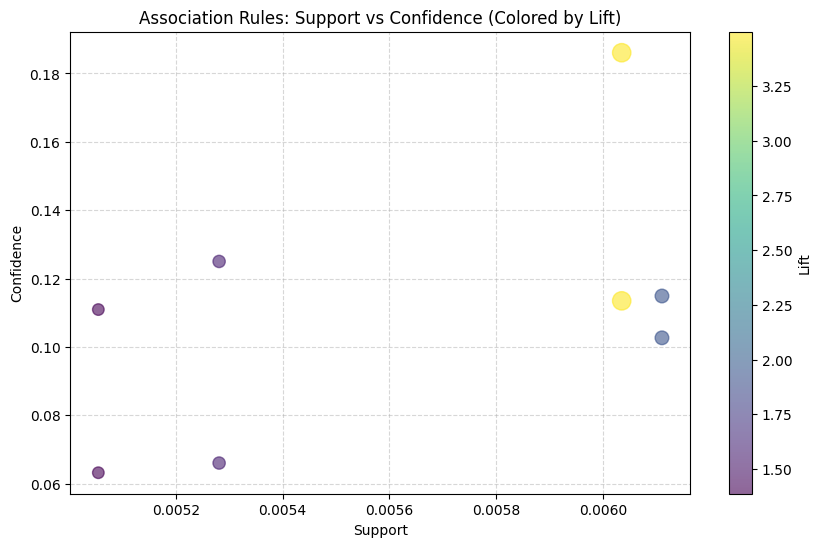

In [55]:
# Visualizing the relationship between Support, Confidence, and Lift
plt.figure(figsize=(10, 6))
scatter = plt.scatter(pairing_rules['support'], pairing_rules['confidence'],
            c=pairing_rules['lift'], cmap='viridis', s=pairing_rules['lift']*50, alpha=0.6)
plt.colorbar(scatter, label='Lift')
plt.title('Association Rules: Support vs Confidence (Colored by Lift)')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Customer Behavior Trends Over Time
In this section, we analyze the evolution of purchasing patterns, specifically looking at the average spend per order and the number of items purchased per transaction.

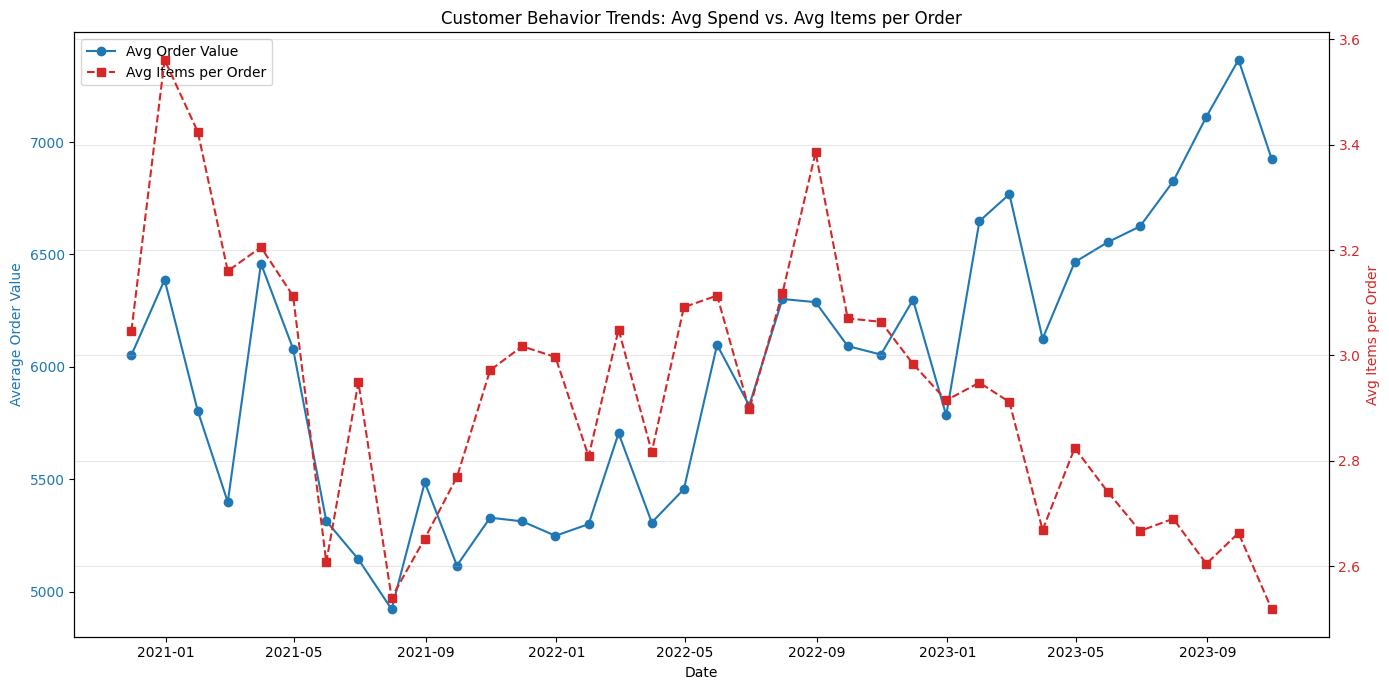

,Avg Order Value,Avg Items per Order,Transaction Volume
Date,,,
2023-06-30 00:00:00+03:00,6624.661994,2.666667,642
2023-07-31 00:00:00+03:00,6825.191860,2.689922,516
2023-08-31 00:00:00+03:00,7112.427165,2.604331,508
2023-09-30 00:00:00+03:00,7365.691288,2.662879,528
2023-10-31 00:00:00+03:00,6924.401606,2.518072,498


In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Order ID to get total spend and total quantity per transaction
order_metrics = df.groupby(['Order ID', 'Date']).agg({
    'Total sales': 'sum',
    'Net quantity': 'sum'
}).reset_index()

# Resample to monthly frequency to see trends
customer_trends = order_metrics.resample('ME', on='Date').agg({
    'Total sales': 'mean',
    'Net quantity': 'mean',
    'Order ID': 'count'
}).rename(columns={'Total sales': 'Avg Order Value', 'Net quantity': 'Avg Items per Order', 'Order ID': 'Transaction Volume'})

# Plotting the trends
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Average Order Value
color1 = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Order Value', color=color1)
line1 = ax1.plot(customer_trends.index, customer_trends['Avg Order Value'], color=color1, marker='o', label='Avg Order Value')
ax1.tick_params(axis='y', labelcolor=color1)

# Create a second y-axis for Average Items per Order
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Avg Items per Order', color=color2)
line2 = ax2.plot(customer_trends.index, customer_trends['Avg Items per Order'], color=color2, marker='s', linestyle='--', label='Avg Items per Order')
ax2.tick_params(axis='y', labelcolor=color2)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title('Customer Behavior Trends: Avg Spend vs. Avg Items per Order')
fig.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

display(customer_trends.tail())

### Customer Segmentation (RFM-style)
We will segment customers based on their **Total Spend** (Monetary) and **Order Frequency**. This helps identify high-value customers and those who purchase most often.

In [58]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Calculate metrics per customer (Order ID is used as the proxy for customer here)
customer_data = df.groupby('Order ID').agg({
    'Total sales': 'sum',
    'Date': 'count'
}).rename(columns={'Total sales': 'TotalSpend', 'Date': 'Frequency'})

# Scale the data for clustering
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_data)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_data['Segment'] = kmeans.fit_predict(scaled_features)

# Display segment characteristics
segment_summary = customer_data.groupby('Segment').agg({
    'TotalSpend': ['mean', 'min', 'max'],
    'Frequency': ['mean', 'count']
})
display(segment_summary)

TotalSpend                    Frequency       
                 mean      min       max      mean  count
Segment                                                  
0         4309.542303      0.0   12000.0  1.800919  10659
1         9116.419123      0.0   60208.0  4.987779   1391
2        18462.104898  10700.0   53150.0  2.170051   1182
3        94143.960000  60000.0  192000.0  2.240000     25

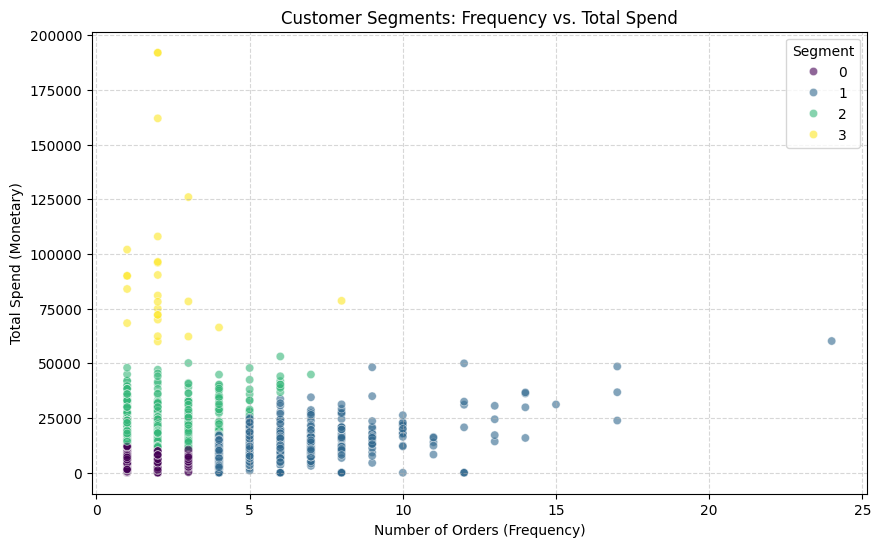

In [59]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=customer_data, x='Frequency', y='TotalSpend', hue='Segment', palette='viridis', alpha=0.6)
plt.title('Customer Segments: Frequency vs. Total Spend')
plt.xlabel('Number of Orders (Frequency)')
plt.ylabel('Total Spend (Monetary)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Sales Forecasting for the Next Quarter
We will use the `Prophet` library to forecast daily sales for the next 90 days based on the historical trends from November 2020 to October 2023.

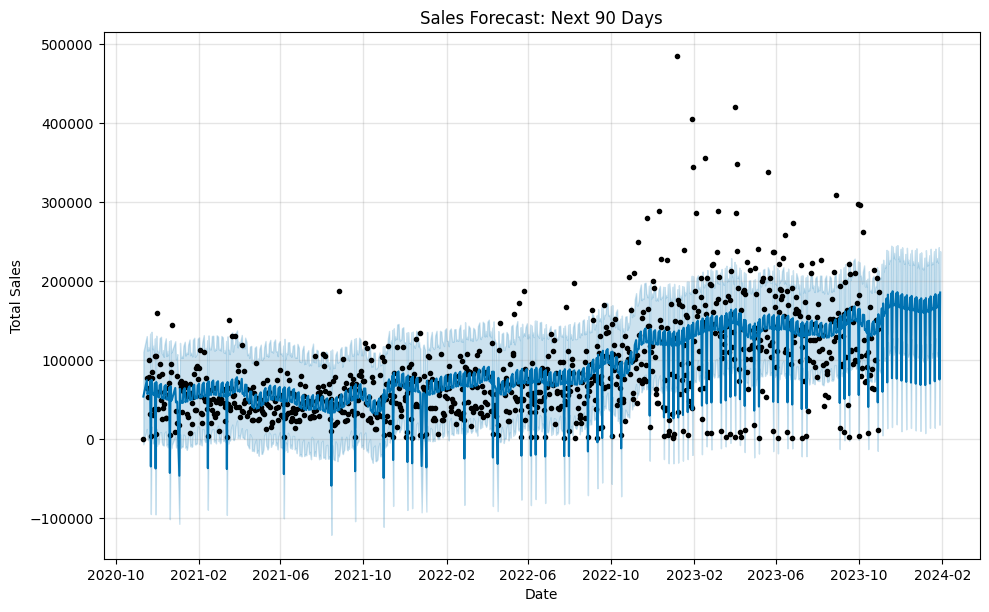

In [60]:
from prophet import Prophet
import pandas as pd

# Prepare data for Prophet: needs columns 'ds' (datestamp) and 'y' (metric to forecast)
# We remove the timezone for Prophet compatibility
forecast_df = df.copy()
forecast_df['Date'] = pd.to_datetime(forecast_df['Date']).dt.tz_localize(None)

daily_sales = forecast_df.groupby(forecast_df['Date'].dt.date)['Total sales'].sum().reset_index()
daily_sales.columns = ['ds', 'y']

# Initialize and fit the model
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(daily_sales)

# Create a dataframe for the next 90 days (one quarter)
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# Display the forecast components
fig1 = model.plot(forecast)
plt.title('Sales Forecast: Next 90 Days')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

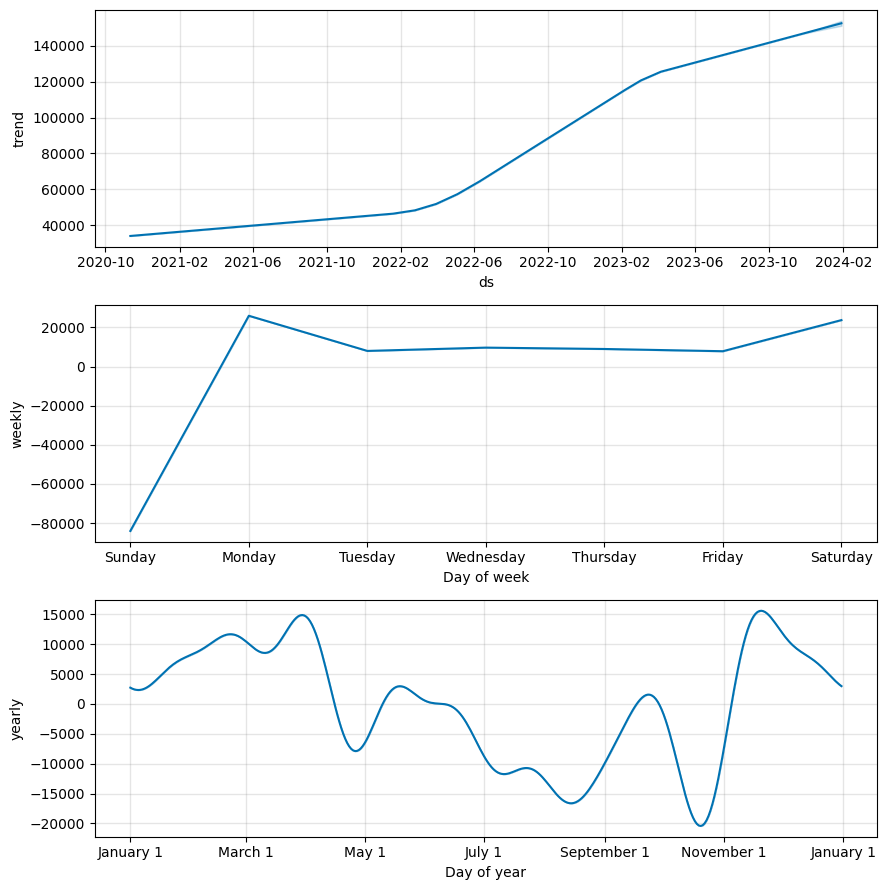

In [61]:
fig2 = model.plot_components(forecast)
plt.show()

### Forecast Summary
The following table shows the predicted sales values for the next quarter, including the lower and upper bounds (uncertainty intervals).

In [63]:
# Extract the forecast for the future period
import pandas as pd

# Ensure we compare datetime objects to avoid the TypeError
max_date = pd.to_datetime(daily_sales['ds'].max())
next_quarter = forecast[forecast['ds'] > max_date][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
next_quarter.columns = ['Date', 'Predicted Sales', 'Lower Bound', 'Upper Bound']

display(next_quarter.head(10))

total_projected = next_quarter['Predicted Sales'].sum()
print(f"Total Projected Sales for the Next Quarter: {total_projected:,.2f}")

,Date,Predicted Sales,Lower Bound,Upper Bound
975,2023-11-01,145948.700532,86955.410032,204147.812205
976,2023-11-02,147214.418808,84584.976082,203479.984272
977,2023-11-03,148069.865714,91419.684399,206305.586816
978,2023-11-04,165975.037056,101754.983844,222470.187394
979,2023-11-05,60271.850229,5169.103295,123280.649495
980,2023-11-06,172149.603447,117091.447851,227393.958416
981,2023-11-07,156093.107032,100413.012593,212507.752054
982,2023-11-08,159607.268658,99547.499863,220649.322197
983,2023-11-09,160641.416524,103446.086793,217416.621396
984,2023-11-10,161117.181387,98865.456109,219510.994677


Total Projected Sales for the Next Quarter: 13,986,999.10


### Historical vs. Predicted Sales Comparison
This visualization overlays our historical daily sales data with the Prophet model's predictions to show the fit and the projected trajectory.

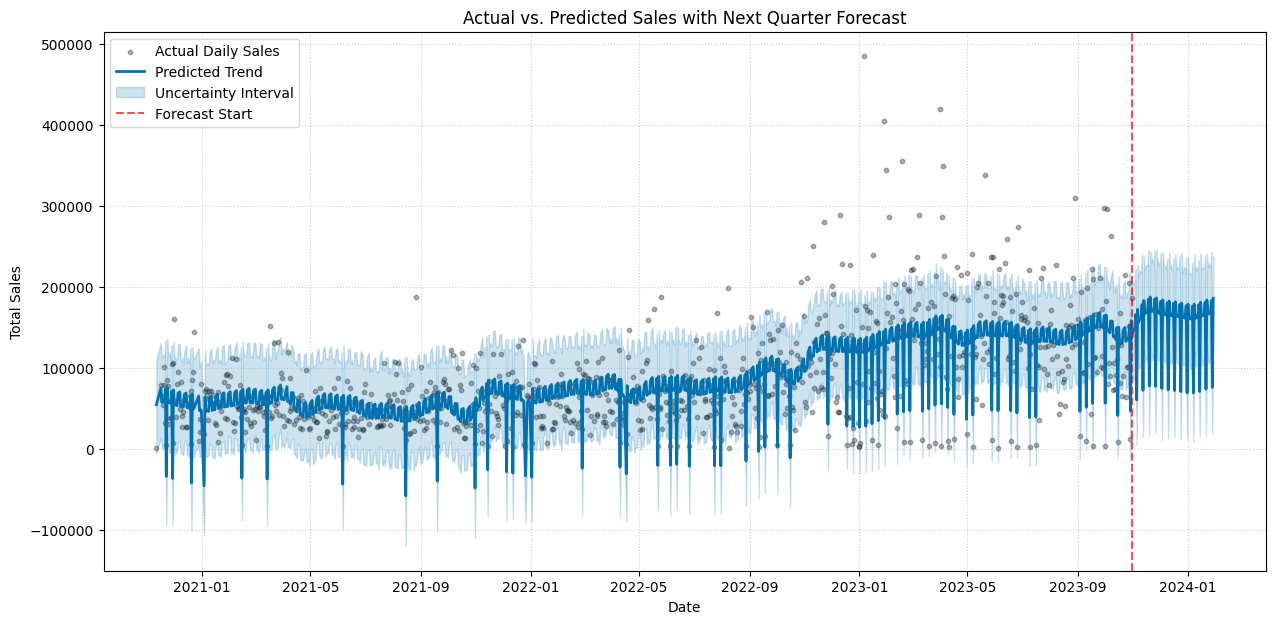

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))

# Plot actual historical sales
plt.scatter(daily_sales['ds'], daily_sales['y'], color='black', s=10, alpha=0.3, label='Actual Daily Sales')

# Plot predicted values (yhat) including the historical period
plt.plot(forecast['ds'], forecast['yhat'], color='#0072B2', linewidth=2, label='Predicted Trend')

# Fill the uncertainty interval
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='#0072B2', alpha=0.2, label='Uncertainty Interval')

# Highlight the start of the forecast
plt.axvline(x=pd.to_datetime(daily_sales['ds'].max()), color='red', linestyle='--', alpha=0.7, label='Forecast Start')

plt.title('Actual vs. Predicted Sales with Next Quarter Forecast')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

### Strategic Promotional Plan

Based on the data-driven insights from Market Basket Analysis (MBA) and Customer Segmentation, the following promotional strategies are recommended:

#### 1. The 'Loyalty Booster' Bundle (Target: Segment 1)
*   **Insight**: Segment 1 customers shop frequently (avg. 5 orders) but with moderate individual spend.
*   **Action**: Implement a 'Subscribe & Save' model for top products like *Aptamil 2* and *Nannycare*.
*   **Goal**: Increase the Average Order Value (AOV) by offering a 5% discount if they add a complementary 'Feeding and Weaning' accessory to their recurring formula order.

#### 2. Logistical Synergy Promotion (Insight: Lift Rules)
*   **Insight**: High Lift (~2.6) was found between specific products and delivery riders (e.g., Rider Peter and Aptamil Stage 2).
*   **Action**: Launch a 'Zone-Based Flash Sale'. On days where delivery density is high for specific riders, offer 'Reduced Shipping' for secondary items (like Baby Diapers) to encourage multi-item baskets.
*   **Goal**: Capitalize on existing delivery routes to increase items-per-order (currently declining at ~2.8).

#### 3. VIP Exclusive Pre-Orders (Target: Segment 3)
*   **Insight**: Segment 3 (25 'Whale' customers) contributes massive volume but shops infrequently.
*   **Action**: Assign a dedicated 'Account Manager' or priority support line for this group. Offer them first-access to new stock of high-demand formula to ensure they don't churn to competitors.
*   **Goal**: Retention of the highest-revenue contributors.

#### 4. 'Basket Filler' Cross-Sells
*   **Insight**: MBA showed low multi-item support at 1%.
*   **Action**: At the 'Point of Sale' (92% of revenue), train staff or update the digital checkout to suggest 'Bathing & Skin Care' items (the 4th largest category) as an add-on for every 'Baby Formula' purchase.
*   **Goal**: Break the single-item purchase habit identified in the behavioral analysis.

### Detailed Metric Analysis: Rider Peter
We are filtering the association rules where 'Rider Peter' (or 'Peter') is either the antecedent or the consequent to understand his specific delivery patterns.

In [65]:
# Filter rules for 'Rider Peter' and 'Peter'
peter_rules = pairing_rules[
    pairing_rules['antecedents'].apply(lambda x: 'Rider Peter' in x or 'Peter' in x) |
    pairing_rules['consequents'].apply(lambda x: 'Rider Peter' in x or 'Peter' in x)
]

# Displaying the key metrics
print(f"Found {len(peter_rules)} specific association rules for Rider Peter.")
display(peter_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift', 'leverage']].sort_values('lift', ascending=False))

Found 4 specific association rules for Rider Peter.


,antecedents,consequents,support,confidence,lift,leverage
4,(Peter),(Aptamil Stage 2 Follow On Milk Powder 800g),0.006035,0.186047,3.497938,0.004310
5,(Aptamil Stage 2 Follow On Milk Powder 800g),(Peter),0.006035,0.113475,3.497938,0.004310
6,(Rider Peter),(Aptamil Stage 2 Follow On Milk Powder 800g),0.006111,0.102662,1.930184,0.002945
7,(Aptamil Stage 2 Follow On Milk Powder 800g),(Rider Peter),0.006111,0.114894,1.930184,0.002945
